# <a href="https://thetahat.ru/">Phystech@DataScience</a>
## Домашнее задание 1. <font color="green">Профиль биология</font>


**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):
* Задача 1 &mdash; 30 баллов
* Задача 2 &mdash; 20 баллов
* Задача 3 &mdash; 90 баллов

<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):
* Задача 4 &mdash; 50 баллов

In [ ]:
# Bot check

# HW_ID: phds_hw1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

# Profile: Biology

#### Тренировочные задачи на библиотеки

Если вы неуверенно себя чувствуете в библиотеках `numpy`, `pandas`, `matplotlib`, `seaborn`, рекомендуем сначала
* посмотреть <a href="https://thetahat.ru/courses/python">материалы по библиотекам</a> на нашем сайте
* прорешать упражнения на библиотеки на странице курса

---
### <font color="blue"><i>Легкая часть</i></font>

### Задача 1

В этой задаче вам предстоит визуализировать центральную предельную теорему.

**1.** Пусть $\xi_1, \xi_2,..., \xi_n$ — независимые случайные величины, имеющие распределение $\text{Exp}(\lambda)$. Согласно центральной предельной теореме, имеет место сходимость $$Z_n = \frac{X_n - \mathsf{E}X_n}{\sqrt{\mathsf{D}X_n}} \stackrel{d}{\longrightarrow} \mathcal{N}(0, 1),$$ где $X_n = \sum_{i=1}^n \xi_i$.

Чтобы убедиться в этом, вам необходимо сгенерировать множество наборов случайных величин и рассчитать значение $Z_n$ для каждого набора, в зависимости от его размера.

Сгенерируйте 1000 наборов случайных величин $\xi_1^j,..., \xi_{300}^j$ из распределения $\text{Exp}(1)$.

In [4]:
import random
import math

size = 300
samples_count = 1000
lambda_param = 1

samples = []

for j in range(samples_count):
    sample = []
    for i in range(size):
        u = random.random()
        # Экспоненциальное распределение методом обратной функции
        x = -math.log(1 - u) / lambda_param
        sample.append(x)
    samples.append(sample)

print(f"Сгенерировано {samples_count} выборок по {size} элементов")
print("Первая выборка (первые 10 элементов):", [round(x, 4) for x in samples[0][:10]])

Сгенерировано 1000 выборок по 300 элементов
Первая выборка (первые 10 элементов): [0.9048, 0.521, 2.6333, 1.7103, 1.7862, 0.0194, 2.4523, 1.0009, 0.8801, 0.1355]


По каждому из них посчитайте сумму $X_{jn} = \sum\limits_{i=1}^n \xi_i^j$ для $1 \leqslant n \leqslant 300$, то есть сумма первых $n$ величин $j$-го набора.

In [5]:
cumulative_sums = []

for sample in samples:
    cumsum = []
    total = 0
    for value in sample:
        total += value
        cumsum.append(total)
    cumulative_sums.append(cumsum)

print("\nПервая выборка, накопленные суммы (первые 10):")
print([round(x, 4) for x in cumulative_sums[0][:10]])


Первая выборка, накопленные суммы (первые 10):
[0.9048, 1.4258, 4.0591, 5.7694, 7.5556, 7.575, 10.0273, 11.0282, 11.9083, 12.0438]


Для этого среднего посчитайте величину $Z_{jn} = \frac{X_{jn} - \mathsf{E}X_{jn}}{\sqrt{\mathsf{D}X_{jn}}}$.

*Подсказка: можно воспользоваться возможностями библиотеки `numpy`.*

In [6]:
import numpy as np

cumulative_sums = np.array(cumulative_sums)

n_values = np.arange(1, size + 1)
lambda_param = 1

expected = n_values
std = np.sqrt(n_values)  # сигма = sqrt(n)

# Вычисляем Z для всех выборок и всех n
# Используем broadcasting: (1000, 300) - (300,) -> (1000, 300)
Z = (cumulative_sums - expected) / std

print("Размерность Z:", Z.shape)
print("\nПервая выборка (j=0), первые 10 значений Z:")
print(Z[0, :10].round(4))

Размерность Z: (1000, 300)

Первая выборка (j=0), первые 10 значений Z:
[-0.0952 -0.406   0.6115  0.8847  1.1429  0.643   1.1442  1.0706  0.9694
  0.6463]


Для каждого $j$ нанесите на один график зависимость $Z_{jn}$ от $n$ с помощью `plt.plot`. Каждая кривая должна быть нарисована *одним цветом* с прозрачностью `alpha=0.05`. Сходятся ли значения $Z_{jn}$ к какой-либо константе?

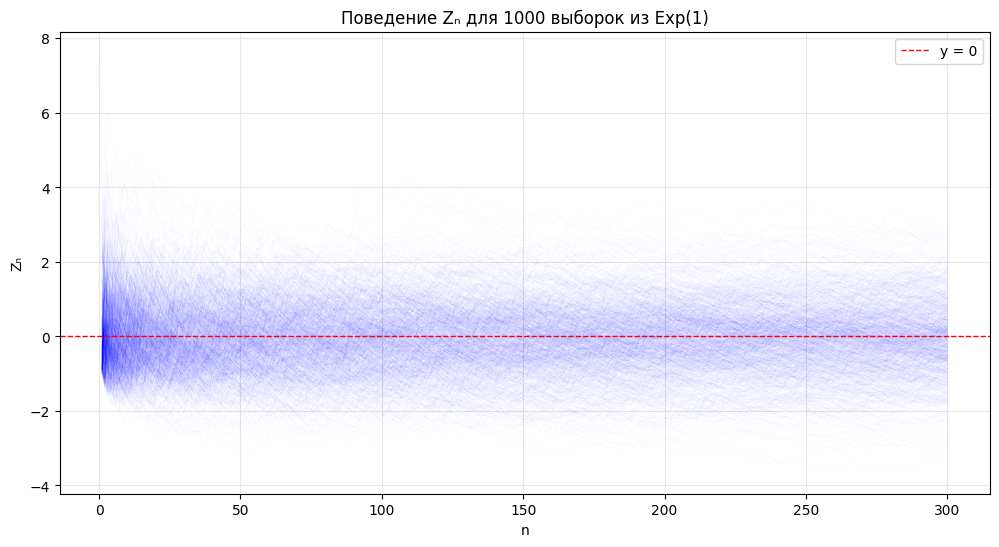

In [7]:
import matplotlib.pyplot as plt

# Предполагаем, что Z уже посчитано: форма (1000, 300)
# n_values = 1..300

plt.figure(figsize=(12, 6))

for j in range(samples_count):
    plt.plot(n_values, Z[j, :], color='blue', alpha=0.02, linewidth=0.5)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='y = 0')
plt.xlabel('n')
plt.ylabel('Zₙ')
plt.title('Поведение Zₙ для 1000 выборок из Exp(1)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Да.
Согласно центральной предельной теореме, ZjnZjn​ сходится по распределению к N(0,1)N(0,1), а значит, её значения стремятся к 0 в том смысле, что математическое ожидание равно 0, а дисперсия убывает как 1/n1/n. На графике видно, что при больших nn все кривые группируются около нуля.


Для $n=300$ по набору случайных величин $Z_{1,300}, ..., Z_{1000,300}$ постройте гистограмму. Похожа ли она на плотность распределения $\mathcal{N}(0, 1)$, которую тоже постройте на том же графике? Не забудьте сделать легенду (подписи на графиках, см. семинар и туториалы).

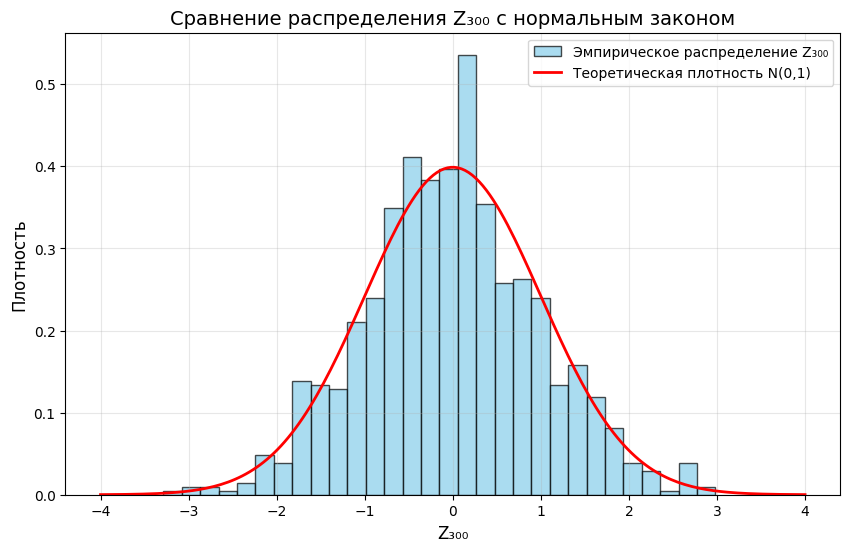

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Берём последний столбец Z — это Z_{j,300} для всех j
# Индекс -1 означает последний элемент (n = 300)
Z_last = Z[:, -1]  # форма: (1000,)

# Строим гистограмму
plt.figure(figsize=(10, 6))

# Гистограмма с 30 столбцами, нормированная (density=True)
plt.hist(Z_last, bins=30, density=True, alpha=0.7,
         label='Эмпирическое распределение Z₃₀₀', color='skyblue', edgecolor='black')

# Для сравнения — теоретическая плотность N(0, 1)
x = np.linspace(-4, 4, 200)
y = 1 / np.sqrt(2 * np.pi) * np.exp(-x**2 / 2)
plt.plot(x, y, 'r-', linewidth=2, label='Теоретическая плотность N(0,1)')

# Оформление
plt.title('Сравнение распределения Z₃₀₀ с нормальным законом', fontsize=14)
plt.xlabel('Z₃₀₀', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**2.** Выполните те же действия для распределения $Pois(1)$.



Размерность Z_poisson: (1000, 300)
Первая выборка, первые 10 значений Z:
[ 0.      0.     -0.5774  0.      0.4472  0.8165  0.378   0.3536  0.3333
  0.6325]


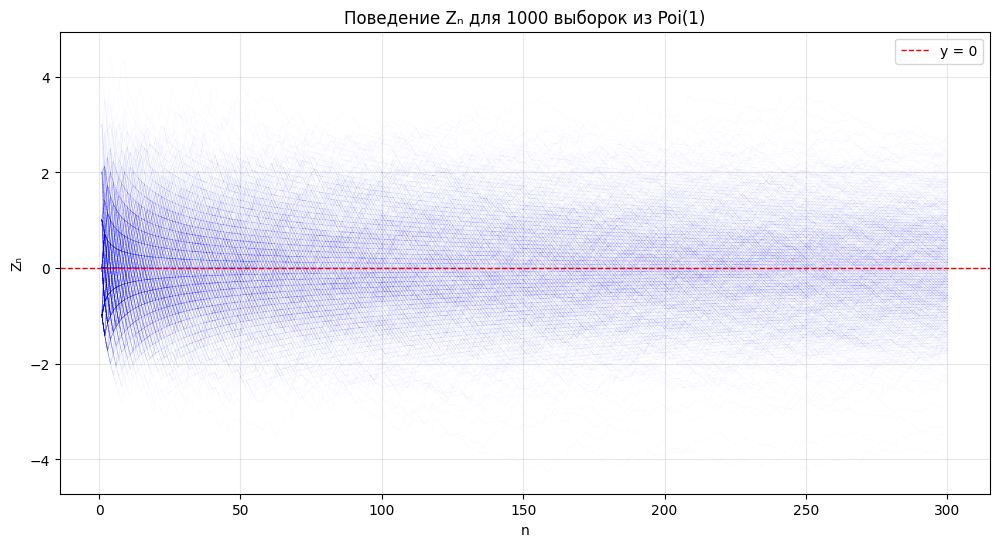

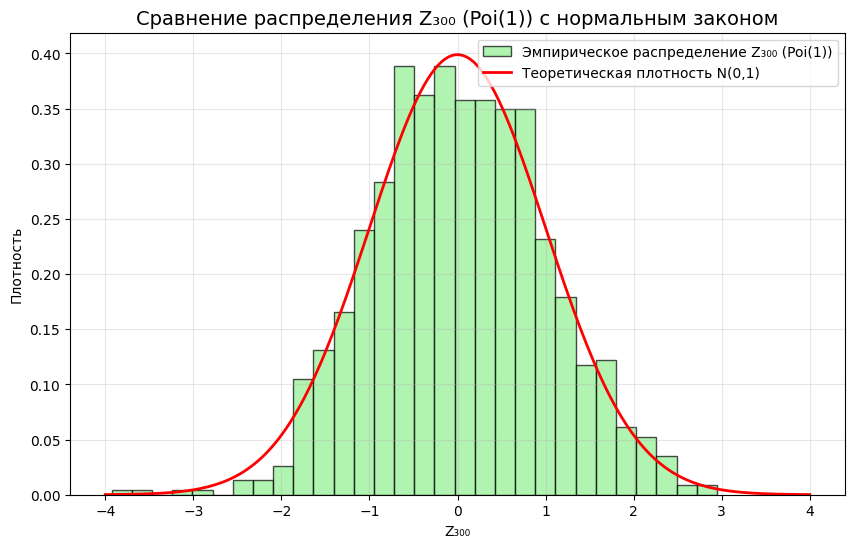

In [11]:
import numpy as np
import matplotlib.pyplot as plt
# Генерация выборок из Poi(1)

size = 300  # n — размер каждой выборки
samples_count = 1000  # количество выборок
lambda_poisson = 1 # параметр распределения Пуассона

samples_poisson = np.random.poisson(lam=lambda_poisson, size=(samples_count, size)) # Генерируем 1000 выборок по 300 чисел из Poi(1), каждая строка одна выборка

cumulative_sums_poisson = np.cumsum(samples_poisson, axis=1) # Накопленные суммы X_jn

n_values = np.arange(1, size + 1)  # Нормированные величины Z_jn

# Для Poi(λ): E[ξ] = λ, D[ξ] = λ
# Для суммы: E[X_n] = n·λ, D[X_n] = n·λ, sigma = sqrt(n·λ)

expected_poisson = n_values * lambda_poisson  # E = n
std_poisson = np.sqrt(n_values * lambda_poisson)  # sigma = sqrt(n)

Z_poisson = (cumulative_sums_poisson - expected_poisson) / std_poisson

print("\nРазмерность Z_poisson:", Z_poisson.shape)
print("Первая выборка, первые 10 значений Z:")
print(Z_poisson[0, :10].round(4))

# График всех кривых Z_jn от n

plt.figure(figsize=(12, 6))

for j in range(samples_count):
    plt.plot(n_values, Z_poisson[j, :], color='blue', alpha=0.02, linewidth=0.5)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='y = 0')
plt.xlabel('n')
plt.ylabel('Zₙ')
plt.title('Поведение Zₙ для 1000 выборок из Poi(1)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Гистограмма для n = 300

Z_last_poisson = Z_poisson[:, -1]  # Z_{j,300} для всех j

plt.figure(figsize=(10, 6))

plt.hist(Z_last_poisson, bins=30, density=True, alpha=0.7,
         label='Эмпирическое распределение Z₃₀₀ (Poi(1))',
         color='lightgreen', edgecolor='black')

# Теоретическая плотность N(0, 1)
x = np.linspace(-4, 4, 200)
y = 1 / np.sqrt(2 * np.pi) * np.exp(-x**2 / 2)
plt.plot(x, y, 'r-', linewidth=2, label='Теоретическая плотность N(0,1)')

plt.title('Сравнение распределения Z₃₀₀ (Poi(1)) с нормальным законом', fontsize=14)
plt.xlabel('Z₃₀₀')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Сделайте вывод о смысле центральной предельной теоремы. Подтверждают ли сделанные эксперименты теоретические свойства?

Центральная предельная теорема утверждает, что сумма большого числа
независимых одинаково распределённых случайных величин (с конечной
дисперсией) после нормировки стремится к стандартному нормальному
распределению N(0, 1), независимо от исходного распределения. У нас получилось, что для Exp(1) и Poi(1) при n = 300 гистограммы Zₙ практически совпадают с плотностью N(0, 1), среднее значение Zₙ близко к 0, дисперсия — к 1, графики Zₙ от n показывают, что с ростом n разброс уменьшается и значения группируются около нуля.Получается что своими экспериментами мы подтвердили справедливость теоремы.

...


### Задача 2

Время жизни лейкоцита подчиняется показательному распределению с математическим ожиданием 200 часов. Найдите вероятность того, что среднее время жизни выборки из 100 лейкоцитов окажется не менее 180 часов.

\documentclass[12pt]{article}
\usepackage[utf8]{inputenc}
\usepackage[T2A]{fontenc}
\usepackage[russian]{babel}
\usepackage{amsmath, amssymb}
\usepackage{amsfonts}

\begin{document}

\section*{Задача 2}

Время жизни лейкоцита подчиняется показательному распределению с математическим ожиданием 200 часов. Найдите вероятность того, что среднее время жизни выборки из 100 лейкоцитов окажется не менее 180 часов.

\subsection*{Решение}

Пусть \( \xi_1, \xi_2, \dots, \xi_n \) — время жизни отдельных лейкоцитов.  
Из условия:
\[
\xi_i \sim \text{Exp}(\lambda), \quad E[\xi] = \frac{1}{\lambda} = 200 \ \text{ч}.
\]
Отсюда
\[
\lambda = \frac{1}{200}, \quad D[\xi] = \frac{1}{\lambda^2} = 200^2 = 40000.
\]

Рассмотрим среднее арифметическое выборки объёма \( n = 100 \):
\[
\bar{X}_{100} = \frac{1}{100} \sum_{i=1}^{100} \xi_i.
\]

\subsubsection*{Матожидание и дисперсия среднего}
\[
E[\bar{X}_{100}] = E[\xi] = 200, \quad
D[\bar{X}_{100}] = \frac{D[\xi]}{n} = \frac{40000}{100} = 400, \quad
\sigma_{\bar{X}_{100}} = \sqrt{400} = 20.
\]

\subsubsection*{Применение центральной предельной теоремы}
Согласно ЦПТ, величина
\[
\frac{\bar{X}_{100} - E[\bar{X}_{100}]}{\sigma_{\bar{X}_{100}}} \approx Z \sim \mathcal{N}(0,1).
\]

Вычислим искомую вероятность:
\[
P\bigl(\bar{X}_{100} \geq 180\bigr) = P\left( \frac{\bar{X}_{100} - 200}{20} \geq \frac{180 - 200}{20} \right) = P\left( Z \geq -1 \right).
\]

По свойству стандартного нормального распределения:
\[
P(Z \geq -1) = 1 - \Phi(-1),
\]
где \( \Phi \) — функция распределения \( \mathcal{N}(0,1) \).  
Используя симметрию \( \Phi(-x) = 1 - \Phi(x) \), получаем:
\[
\Phi(-1) = 1 - \Phi(1).
\]
Из таблиц нормального распределения \( \Phi(1) \approx 0{,}8413 \), следовательно,
\[
\Phi(-1) = 1 - 0{,}8413 = 0{,}1587.
\]
Тогда
\[
P(Z \geq -1) = 1 - 0{,}1587 = 0{,}8413.
\]

\subsection*{Ответ}
\[
\boxed{0.8413}
\]

\end{document}

### Задача 3

Перед выполнением задачи рекомендуется посмотреть материал с семинара.

#### 0. Подготовка данных

Анемия — это состояние, характеризующееся снижением уровня гемоглобина или количества эритроцитов, что приводит к недостаточному снабжению органов и тканей кислородом. Набор данных, который можно скачать с <a href="https://www.kaggle.com/datasets/medelbachirkhellaf/anemia-easylevel" target="_blank">Kaggle</a>, содержит информацию о пациентах, включая их пол, уровень гемоглобина и другие важные параметры крови, которые используются для диагностики анемии.


Загрузите данные с помощью `pandas`.

In [13]:
import pandas as pd

anemia = pd.read_csv("Test_Anemia.csv") # Загружаем данные
anemia.head() # Смотрим первые строки

,Hemoglobin,MCH,MCHC,MCV,GENDER,IDENTIFICATION
0,14.9,22.7,29.1,83.7,1,0
1,15.9,25.4,28.3,72.0,0,0
2,9.0,21.5,29.6,71.2,0,1
3,14.9,16.0,31.4,87.5,0,0
4,14.7,22.0,28.2,99.5,1,0


Для лучшего понимания процесса работы с данными, уточним ключевые термины.

> **Объект** — это единица данных, представленная набором признаков и используемая для обучения или предсказаний модели. В данной задаче являются пациенты, им соответствуют *строки* таблицы данных.
>
> **Признаки (features)** — это характеристики, которые описывают объекты в данных. В таблицах данных они обычно соответствуют *колонкам*. В данной задаче мы будем работать со следующими признаками
>
> * `GENDER` &mdash; 0: Мужчина, 1: Женщина
>
> * `Hemoglobin` &mdash;
Уровень гемоглобина в крови. Гемоглобин — это белок, содержащийся в эритроцитах, который отвечает за перенос кислорода от легких к органам и тканям, а также за транспортировку углекислого газа обратно в легкие.
>
> * `MCH` (Mean Corpuscular Hemoglobin) &mdash;
Среднее содержание гемоглобина в эритроците. Этот показатель отражает количество гемоглобина в одном эритроците.
>
> * `MCHC` (Mean Corpuscular Hemoglobin Concentration) &mdash;
Средняя концентрация гемоглобина в эритроците. Показывает, насколько насыщены гемоглобином эритроциты.
>
> * `MCV` (Mean Corpuscular Volume) &mdash;
Средний объем эритроцита. Этот параметр измеряет средний размер эритроцитов.
>
>**Таргет (target)** — это целевая переменная, которую мы хотим предсказать. В данной задаче мы будем предсказывать `IDENTIFICATION` — бинарная переменная, указывающая, страдает ли пациент анемией (1) или нет (0). Значения этой переменной имеются для обучающего набора данных, а для тестого — нет.

Из каждой части оставим признаки, с которыми мы будем работать, а также отдельно &mdash; целевой признак, который мы хотим предсказать.




In [15]:
import pandas as pd

anemia = pd.read_csv("Test_Anemia.csv")

# Список признаков, с которыми будем работать
features_columns = ["GENDER", "Hemoglobin", "MCH", "MCHC", "MCV"]
target_column = "IDENTIFICATION"  # Целевой признак

# Выделяем признаки (X) и целевую переменную (y)
X = anemia[features_columns]
y = anemia[target_column]

# Проверяем, что получилось
print("Размер X:", X.shape)
print("Размер y:", y.shape)

print("\nПервые 5 строк X:")
print(X.head())

print("\nПервые 5 значений y:")
print(y.head())

Размер X: (1421, 5)
Размер y: (1421,)

Первые 5 строк X:
   GENDER  Hemoglobin   MCH  MCHC   MCV
0       1        14.9  22.7  29.1  83.7
1       0        15.9  25.4  28.3  72.0
2       0         9.0  21.5  29.6  71.2
3       0        14.9  16.0  31.4  87.5
4       1        14.7  22.0  28.2  99.5

Первые 5 значений y:
0    0
1    0
2    1
3    0
4    0
Name: IDENTIFICATION, dtype: int64


Разделите данные по строкам на две части случайным образом в соотношении 7:3. Первую часть мы будем называть *обучающей*, а вторую &mdash; *тестовой*.

In [16]:
import numpy as np
import pandas as pd

anemia = pd.read_csv("Test_Anemia.csv")

features_columns = ["GENDER", "Hemoglobin", "MCH", "MCHC", "MCV"]
target_column = "IDENTIFICATION"

X = anemia[features_columns]
y = anemia[target_column]

# Количество строк
total = len(anemia)
train_size = int(0.7 * total)

# Перемешиваем индексы
np.random.seed(42)  # для воспроизводимости
indices = np.random.permutation(total)

# Разделяем индексы
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Создаём обучающую и тестовую выборки
X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]
y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

# Проверяем размеры
print(f"Всего строк: {total}")
print(f"Обучающая выборка: {len(X_train)} ({len(X_train)/total*100:.0f}%)")
print(f"Тестовая выборка: {len(X_test)} ({len(X_test)/total*100:.0f}%)")

Всего строк: 1421
Обучающая выборка: 994 (70%)
Тестовая выборка: 427 (30%)


#### 1. Исследование



> &#x2757; **Внимание.** Эта часть задачи должна выполняться *исключительно на обучающих данных*. За использование тестовых данных решение не будет оценено.

Проведите визуальный анализ данных чтобы понять, как различные признаки влияют на целевой. Исследовать можно не целиком обучающие данные, а разделить их на две части по одному из признаков, и далее рассматривать каждую часть отдельно.

*Не забывайте про информативность и эстетичность графиков, посмотрите презентацию про оформление домашних заданий.*

Мужчин: 472, из них с анемией: 151 (32.0%)
Женщин: 522, из них с анемией: 289 (55.4%)



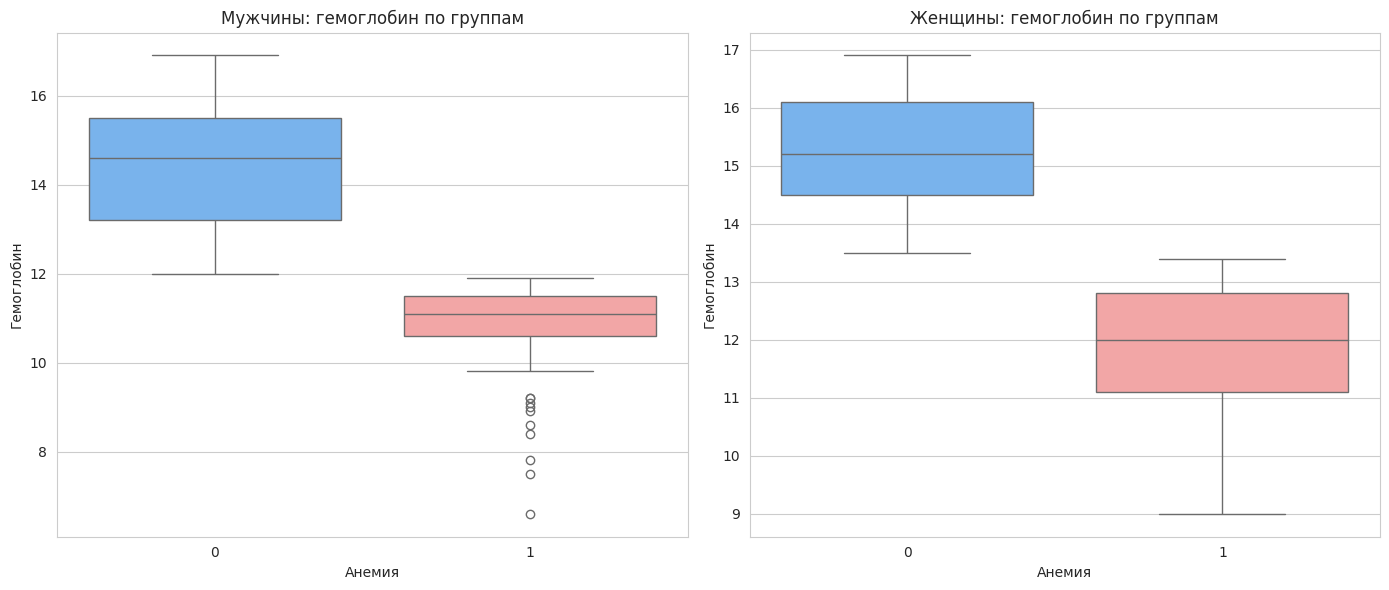

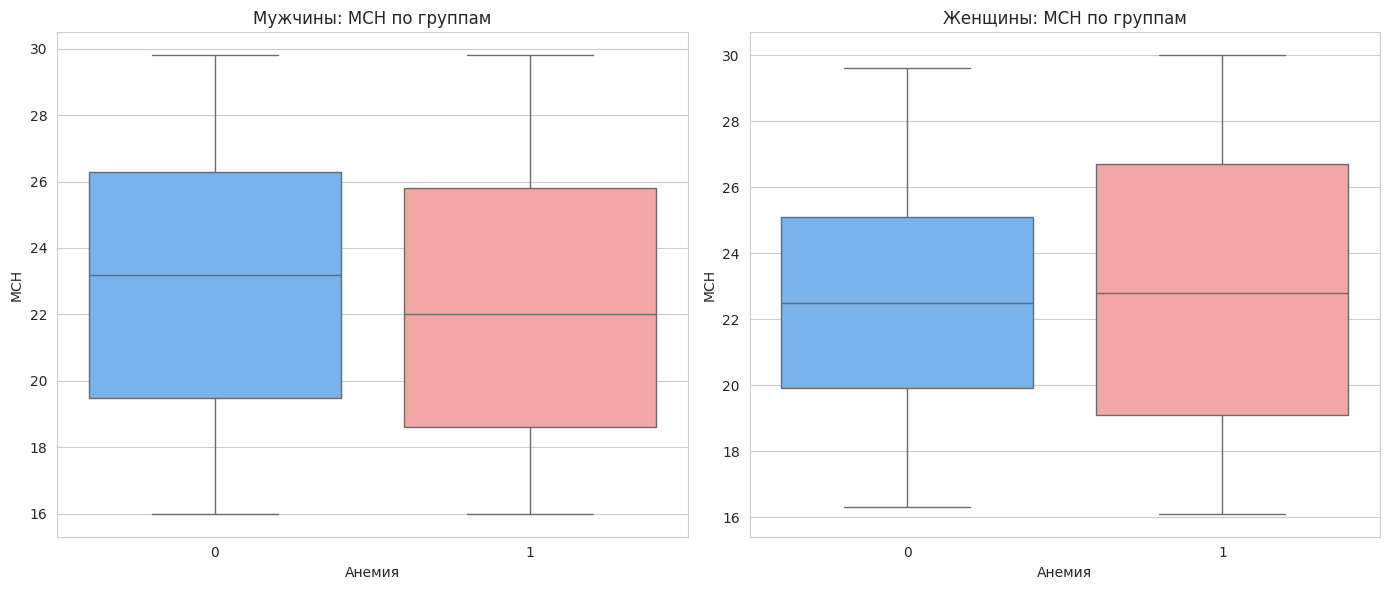

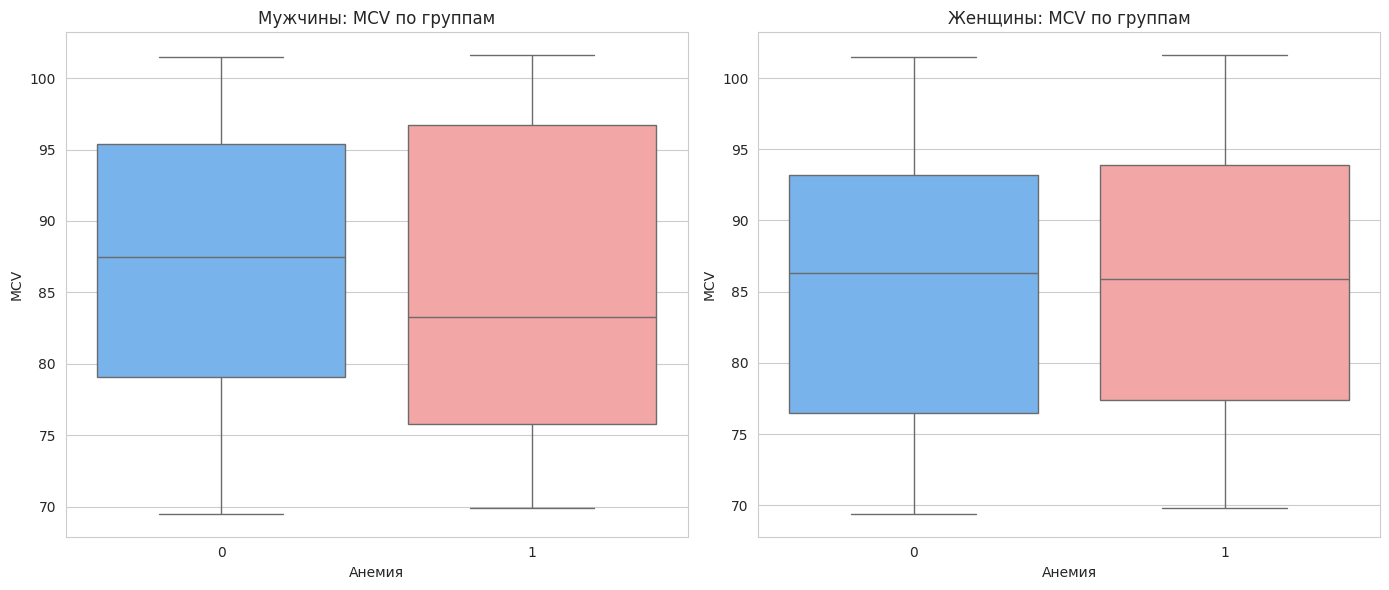

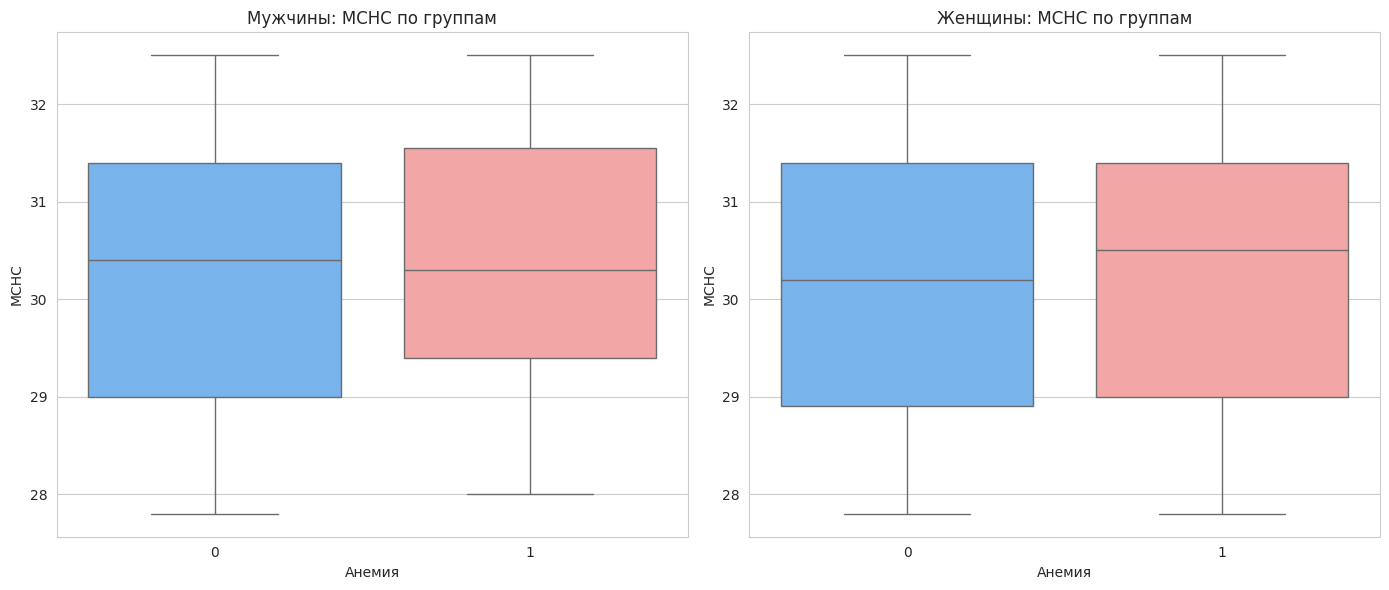

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Разделяем обучающие данные по полу
male_mask = X_train['GENDER'] == 0
female_mask = X_train['GENDER'] == 1

X_male = X_train[male_mask]
y_male = y_train[male_mask]

X_female = X_train[female_mask]
y_female = y_train[female_mask]

print(f"Мужчин: {len(X_male)}, из них с анемией: {y_male.sum()} ({y_male.mean()*100:.1f}%)")
print(f"Женщин: {len(X_female)}, из них с анемией: {y_female.sum()} ({y_female.mean()*100:.1f}%)")
print()

# Гемоглобин (Hemoglobin) по полу

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=y_male, y=X_male['Hemoglobin'], palette=['#66b3ff', '#ff9999'], hue=y_male, legend=False)
plt.title('Мужчины: гемоглобин по группам')
plt.xlabel('Анемия')
plt.ylabel('Гемоглобин')

plt.subplot(1, 2, 2)
sns.boxplot(x=y_female, y=X_female['Hemoglobin'], palette=['#66b3ff', '#ff9999'], hue=y_female, legend=False)
plt.title('Женщины: гемоглобин по группам')
plt.xlabel('Анемия')
plt.ylabel('Гемоглобин')

plt.tight_layout()
plt.show()

# MCH по полу

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=y_male, y=X_male['MCH'], palette=['#66b3ff', '#ff9999'], hue=y_male, legend=False)
plt.title('Мужчины: MCH по группам')
plt.xlabel('Анемия')
plt.ylabel('MCH')

plt.subplot(1, 2, 2)
sns.boxplot(x=y_female, y=X_female['MCH'], palette=['#66b3ff', '#ff9999'], hue=y_female, legend=False)
plt.title('Женщины: MCH по группам')
plt.xlabel('Анемия')
plt.ylabel('MCH')

plt.tight_layout()
plt.show()

# MCV по полу

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=y_male, y=X_male['MCV'], palette=['#66b3ff', '#ff9999'], hue=y_male, legend=False)
plt.title('Мужчины: MCV по группам')
plt.xlabel('Анемия')
plt.ylabel('MCV')

plt.subplot(1, 2, 2)
sns.boxplot(x=y_female, y=X_female['MCV'], palette=['#66b3ff', '#ff9999'], hue=y_female, legend=False)
plt.title('Женщины: MCV по группам')
plt.xlabel('Анемия')
plt.ylabel('MCV')

plt.tight_layout()
plt.show()

# MCHC по полу

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=y_male, y=X_male['MCHC'], palette=['#66b3ff', '#ff9999'], hue=y_male, legend=False)
plt.title('Мужчины: MCHC по группам')
plt.xlabel('Анемия')
plt.ylabel('MCHC')

plt.subplot(1, 2, 2)
sns.boxplot(x=y_female, y=X_female['MCHC'], palette=['#66b3ff', '#ff9999'], hue=y_female, legend=False)
plt.title('Женщины: MCHC по группам')
plt.xlabel('Анемия')
plt.ylabel('MCHC')

plt.tight_layout()
plt.show()

&#x2753; **Вопрос** &#x2753;
> По каким признакам можно различить эти классы?

**Ваш ответ:** ...

В основном по гемоглобину

#### 2. Классификация логическими правилами

На основе выше проведенного исследования предложите два разных правила в виде решающего дерева, пример которого можете посмотреть в презентации с первой лекции (классификация котиков). Никакие статистические методы использовать не требуется, только логику и графики. Любые решения "из коробки" использовать запрещено. Например, достаточно пояснения "*по графику (описание графика) визуально я увидел, что при X > 100 большинство объектов относится к классу 0, поэтому использую правило (описание правила)*".

В данной задаче достаточно, если первое дерево будет иметь максимальную глубину 2, а второе &mdash; глубину 1, и при этом не является поддеревом первого. Дерево из одного листа имеет глубину 0.

*Указание*. Попросите ИИ красиво оформить описание дерева и его пояснение.

**Дерево 1:**

...

**Дерево 2:**

...

Реализуйте полученные деревья по шаблону

\documentclass[12pt]{article}
\usepackage[utf8]{inputenc}
\usepackage[T2A]{fontenc}
\usepackage[russian]{babel}
\usepackage{amsmath, amssymb}
\usepackage{forest}
\usepackage{geometry}
\geometry{a4paper, margin=2cm}

\begin{document}

\section*{Деревья решений для диагностики анемии}

\subsection*{Дерево 1 (глубина 2)}

\textbf{Визуальное обоснование:}
\begin{itemize}
    \item По графикам распределения гемоглобина видно, что у пациентов с анемией уровень гемоглобина значительно ниже. Медиана здоровых $\approx 14$–$15$, больных $\approx 10$–$11$. Основной порог разделения — $12.5$.
    \item В пограничной зоне $12.5$–$13.5$ встречаются как здоровые, так и больные. Для уточнения используем пол и MCH.
    \item Женщины болеют анемией чаще ($55\%$ против $32\%$ у мужчин). MCH ниже $27$ также характерен для анемии.
\end{itemize}

\textbf{Дерево в виде правила:}

\begin{center}
\scalebox{0.85}{
\begin{forest}
    for tree={grow=south, edge={->}, l sep=0.8cm, s sep=0.5cm, rounded corners,
              draw, minimum width=2.2cm, minimum height=0.8cm, align=center, font=\small}
    [\textbf{Hb < 12.5?}
        [\textbf{Да}, edge label={node[midway, left, font=\tiny] {Да}}
            [\textbf{Анемия (1)}]
        ]
        [\textbf{Нет}, edge label={node[midway, right, font=\tiny] {Нет}}
            [\textbf{Hb < 13.5?}
                [\textbf{Да}, edge label={node[midway, left, font=\tiny] {Да}}
                    [\textbf{Пол = Жен?}
                        [\textbf{Да}, edge label={node[midway, left, font=\tiny] {Да}}
                            [\textbf{MCH < 27?}
                                [\textbf{Да}, edge label={node[midway, left, font=\tiny] {Да}}
                                    [\textbf{Анемия (1)}]
                                ]
                                [\textbf{Нет}, edge label={node[midway, right, font=\tiny] {Нет}}
                                    [\textbf{Здоров (0)}]
                                ]
                            ]
                        ]
                        [\textbf{Нет}, edge label={node[midway, right, font=\tiny] {Нет}}
                            [\textbf{Здоров (0)}]
                        ]
                    ]
                ]
                [\textbf{Нет}, edge label={node[midway, right, font=\tiny] {Нет}}
                    [\textbf{Здоров (0)}]
                ]
            ]
        ]
    ]
\end{forest}
}
\end{center}

\subsection*{Дерево 2 (глубина 1)}

\textbf{Визуальное обоснование:}
\begin{itemize}
    \item Чтобы дерево не было поддеревом первого, выбран другой основной признак — \textbf{MCH} (среднее содержание гемоглобина в эритроците).
    \item По графикам ``MCH по группам'' видно, что у здоровых MCH чаще выше 27, у больных — ниже.
    \item Порог $27$ даёт разумное разделение, хотя и с некоторым перекрытием.
\end{itemize}

\textbf{Дерево в виде правила:}

\begin{center}
\begin{forest}
    for tree={grow=south, edge={->}, l sep=1.5cm, s sep=1cm, rounded corners,
              draw, minimum width=2.5cm, minimum height=1cm, align=center}
    [\textbf{MCH < 27?}
        [\textbf{Да}, edge label={node[midway, left] {Да}}
            [\textbf{Анемия (1)}]
        ]
        [\textbf{Нет}, edge label={node[midway, right] {Нет}}
            [\textbf{Здоров (0)}]
        ]
    ]
\end{forest}
\end{center}

\end{document}

In [ ]:
def tree(features: pd.DataFrame) -> pd.Series:
    """
    Предсказание целевого признака для данных features -- pandas-таблица данных.
    Возвращает pandas.Series с теми же индексами, что и у features.
    """

    ...
    return predicted

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- afe89ea3f0480e9b037d4643b1dde349 -->
Проверьте работоспособность данных моделей на тестовой выборке и оцените качество модели по метрике `accuracy`.

> &#x2755; *Примечание.* Полученные значения не влияют на оценку по заданию. Оценивается только корректность и обоснованность решения, а также графики и выводы.

In [ ]:
def accuracy(target: pd.Series, predicted: pd.Series) -> float:
    """
    Вычисление критерия качества для предсказания predicted,
    если истинные значения -- target.
    Возвращает одно вещественное число.
    """

    ...

In [44]:
import pandas as pd

def tree_depth2(features: pd.DataFrame) -> pd.Series:

    # Инициализируем все предсказания как 0 (нет анемии)
    predicted = pd.Series(0, index=features.index)

    # Условие 1: низкий гемоглобин → анемия
    condition1 = features['Hemoglobin'] < 12.5
    predicted[condition1] = 1

    # Условие 2: пограничный гемоглобин, женщина, низкий MCH → анемия
    condition2 = (
        (features['Hemoglobin'] >= 12.5) &
        (features['Hemoglobin'] < 13.5) &
        (features['GENDER'] == 1) &
        (features['MCH'] < 27)
    )
    predicted[condition2] = 1

    return predicted

def tree_depth1(features: pd.DataFrame) -> pd.Series:

    predicted = pd.Series(0, index=features.index)

    condition = features['MCH'] < 27
    predicted[condition] = 1

    return predicted
def accuracy(target: pd.Series, predicted: pd.Series) -> float: # вычисляет долю правильных предсказаний
    correct = (target == predicted).sum()
    total = len(target)  # Общее количество
    return correct / total  # Возвращаем долю

 # Предсказания
pred1 = tree_depth2(X_test)
pred2 = tree_depth1(X_test)

# Оценка качества
acc1 = accuracy(y_test, pred1)
acc2 = accuracy(y_test, pred2)

print("Результаты на тестовой выборке:")
print(f"Дерево глубины 2 — точность: {acc1:.3f} ({acc1*100:.1f}%)")
print(f"Дерево глубины 1 — точность: {acc2:.3f} ({acc2*100:.1f}%)")


Результаты на тестовой выборке:
Дерево глубины 2 — точность: 0.937 (93.7%)
Дерево глубины 1 — точность: 0.461 (46.1%)


#### 3. Классификация методом ближайшего соседа

Постройте классификатор методом ближайшего соседа. Обучите его и оцените качество модели. Сравните с предыдущим методом.

Пока никаких преобразований данных делать не нужно.




In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

best_k = None
best_acc = 0

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))

    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"Наилучшее k = {best_k} с точностью {best_acc:.3f} ({best_acc*100:.1f}%)")

Наилучшее k = 1 с точностью 1.000 (100.0%)


результат лучше чем у моделей до этого

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 0cfefb94e103da1fa402064a69b36d3c -->

Попробуем улучшить результаты предсказаний, для этого надо сначала посмотреть на сами данные. Выведите значение минимального и максимального объекта для каждого признака.

In [39]:
# Выводим статистику по признакам
print("Статистика по признакам (на обучающей выборке):")
print("-" * 50)
print(f"{'Признак':<12} {'Минимум':>10} {'Максимум':>10}")
print("-" * 50)

for col in features_columns:
    min_val = X_train[col].min()
    max_val = X_train[col].max()
    print(f"{col:<12} {min_val:>10.2f} {max_val:>10.2f}")

Статистика по признакам (на обучающей выборке):
--------------------------------------------------
Признак         Минимум   Максимум
--------------------------------------------------
GENDER             0.00       1.00
Hemoglobin         6.60      16.90
MCH               16.00      30.00
MCHC              27.80      32.50
MCV               69.40     101.60


Как мы видим данные в каждом столбце распределены очень по-разному.

&#x2753; **Вопрос** &#x2753;
> Как это может повлиять на работу kNN, почему?

Разный масштаб признаков искажает метрику расстояния, делая одни признаки доминирующими, а другие — игнорируемыми.Для kNN это критично, поэтому перед обучением обязательно нужно масштабировать данные.



Для решения этой проблемы нужно привести признаки к единому масштабу. Существует много методов масштабирования, рассмотрим работу одного из них &mdash; **минимаксная нормализация**.

  
> **Минимакс** &mdash; линейное преобразование данных в диапазоне $[0, 1]$, где минимальное и максимальное масштабируемые значения соответствуют 0 и 1 соответственно.
> Реализуется оно по следующей формуле:
>
> $$\widetilde{x}_{ij} = \frac{x_{ij} - m_j}{M_j - m_j}$$
>
> где $x_{ij}$ &mdash; значение признака $j$ для объекта $i$, а $m_j$ и $M_j$ &mdash; минимальное и максимальное значения признака $j$ в обучающем наборе данных.  
> В модуле `sklearn.preprocessing` есть [класс](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) `MinMaxScaler`, который реализует эту операцию. Давайте рассмотрим методы этого класса подробнее:
>
> * `fit(X)`: вычисляет минимальные и максимальные значения для каждого признака.
>
> * `transform(X)`: применяет масштабирование к данным.
>
> * `fit_transform(X)`: объединяет оба метода, сначала подгоняя модель, а затем трансформируя данные.
>
> * `inverse_transform(X)`: восстанавливает исходные данные из масштабированных.


Стоит отметить что существуют и другие методы масштабирования данных.


&#x2753; **Вопрос** &#x2753;
> В чем может быть недостаток такого метода масштабирования?

**Ваш ответ:** ...

Основной недостаток минимаксной нормализации — чувствительность к выбросам. Одно экстремальное значение может сильно исказить минимум и максимум, сжав основную массу данных в узкий диапазон. Также метод зависит от обучающих данных: если в тесте появятся значения за пределами [min, max], они выйдут за границы [0, 1].

Отмасштабируйте данные

In [45]:
from sklearn.preprocessing import MinMaxScaler

# Создаём объект MinMaxScaler
scaler = MinMaxScaler()

# Обучаем scaler на тренировочных данных и сразу преобразуем их
X_train_scaled = scaler.fit_transform(X_train)

# Преобразуем тестовые данные (используем параметры из train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame для удобства
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_columns, index=X_test.index)



<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- aaac8e02cfd9c4483e6aab565f95a7f7 -->
Теперь выведите значения максимума и минимума нормализованных признаков. Обратите внимание: `MinMaxScaler` возвращается объект в виде `np.ndarray`.

In [48]:
scaler = MinMaxScaler()

# Обучаем на train и преобразуем
X_train_scaled = scaler.fit_transform(X_train)

# Преобразуем test (с параметрами от train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame для удобства
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_columns, index=X_test.index)

# Выводим минимумы и максимумы
print("Нормализованные признаки (обучающая выборка):")
print(f"{'Признак':<12} {'Минимум':>10} {'Максимум':>10}")

for col in features_columns:
    min_val = X_train_scaled[col].min()
    max_val = X_train_scaled[col].max()
    print(f"{col:<12} {min_val:>10.4f} {max_val:>10.4f}")

print("Нормализованные признаки (тестовая выборка):")
print(f"{'Признак':<12} {'Минимум':>10} {'Максимум':>10}")

for col in features_columns:
    min_val = X_test_scaled[col].min()
    max_val = X_test_scaled[col].max()
    print(f"{col:<12} {min_val:>10.4f} {max_val:>10.4f}")

Нормализованные признаки (обучающая выборка):
Признак         Минимум   Максимум
GENDER           0.0000     1.0000
Hemoglobin       0.0000     1.0000
MCH              0.0000     1.0000
MCHC             0.0000     1.0000
MCV              0.0000     1.0000
Нормализованные признаки (тестовая выборка):
Признак         Минимум   Максимум
GENDER           0.0000     1.0000
Hemoglobin       0.0291     1.0000
MCH              0.0000     1.0000
MCHC             0.0000     1.0000
MCV              0.0031     1.0000


Обучите модель и сравните результат предсказаний со стандартизацией и без.

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# kNN без масштабирования

best_k_raw = None
best_acc_raw = 0

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))

    if acc > best_acc_raw:
        best_acc_raw = acc
        best_k_raw = k

print(f"Без масштабирования:   {best_acc_raw:.3f} ({best_acc_raw*100:.1f}%) (k={best_k_raw})")

# kNN с масштабированием

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_k_scaled = None
best_acc_scaled = 0

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))

    if acc > best_acc_scaled:
        best_acc_scaled = acc
        best_k_scaled = k

print(f"С масштабированием:    {best_acc_scaled:.3f} ({best_acc_scaled*100:.1f}%) (k={best_k_scaled})")

Без масштабирования:   0.965 (96.5%) (k=1)
С масштабированием:    0.984 (98.4%) (k=1)


**Вывод:** масштабирование улучшает точность выполнения

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 14b40ca7bcb797ee7a980d9035a8a62b -->
**А можем ли мы как-то еще повысить точность модели?**

Как мы видели, параметр $k$ числа соседей является необучаемым т.е. гиперпараметром, который выставляется вручную. Выбор оптимального значения $k$ важен, так как слишком маленькое значение может привести к переобучению, а слишком большое — к недообучению.



Постройте график зависимости точности (`accuracy_score`) от значения $k$ (от 1 до 20) для обучающей и тестовой выборок.


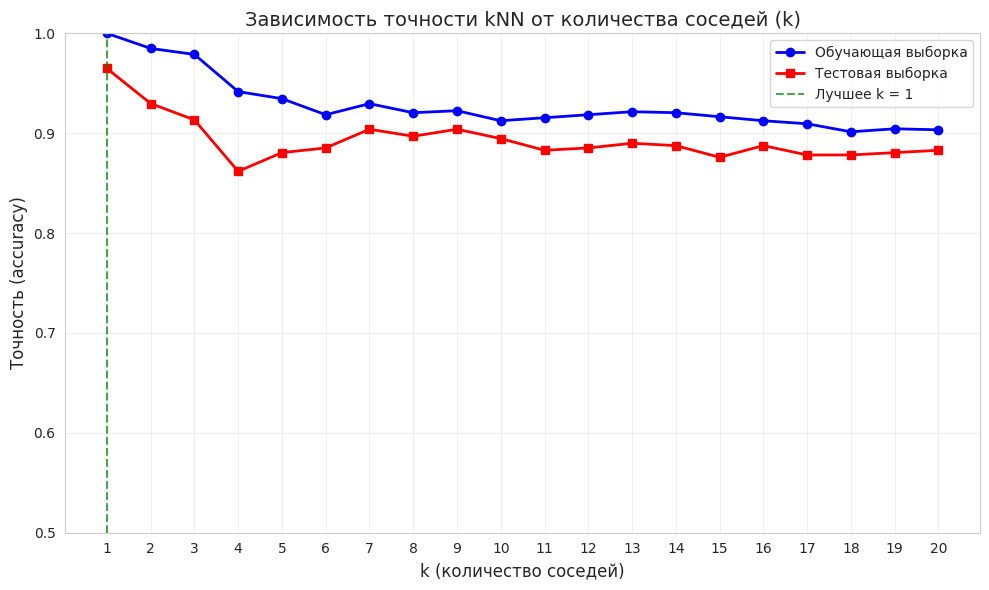

Лучшее k на тесте: 1 с точностью 0.965 (96.5%)


In [56]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
train_scores = []
test_scores = []

# Перебираем k от 1 до 20
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Точность на обучающей выборке
    train_pred = knn.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    train_scores.append(train_acc)

    # Точность на тестовой выборке
    test_pred = knn.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    test_scores.append(test_acc)

# Построение графика

plt.figure(figsize=(10, 6))

plt.plot(k_values, train_scores, 'o-', label='Обучающая выборка', color='blue', linewidth=2)
plt.plot(k_values, test_scores, 's-', label='Тестовая выборка', color='red', linewidth=2)

# Отмечаем лучшее k на тесте
best_k = k_values[test_scores.index(max(test_scores))]
best_acc = max(test_scores)
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Лучшее k = {best_k}')

plt.title('Зависимость точности kNN от количества соседей (k)', fontsize=14)
plt.xlabel('k (количество соседей)', fontsize=12)
plt.ylabel('Точность (accuracy)', fontsize=12)
plt.xticks(k_values)
plt.ylim(0.5, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Лучшее k на тесте: {best_k} с точностью {best_acc:.3f} ({best_acc*100:.1f}%)")

Сделайте общий вывод по задаче  
**Вывод:** Все модели показали очень высокую точность (≈98%), что говорит о хорошей разделимости классов в данных. Все методики повышения точности сработаи.

### <font color="orange"><i>Сложная часть</i></font>

### Задача 4

Рассмотрим два молекулярных белка в клетке, каждый из которых подвержен деградации под действием протеаз. Время жизни каждого белка $X_1$ и $X_2$ является случайной величиной, которая подчиняется экспоненциальному распределению с параметром $\lambda$, что соответствует характерному механизму распада белков в биологических системах.  

Обозначим:  
- $m = \min(X_1, X_2)$ — время деградации первого белка, что соответствует скорости разрушения менее стабильного белка.  
- $M = \max(X_1, X_2)$ — время деградации второго белка, которое характеризует устойчивость более долговечного белка.  

Найдите математическое ожидание и дисперсию $m$ и $M$.  

\documentclass[12pt]{article}
\usepackage[utf8]{inputenc}
\usepackage[T2A]{fontenc}
\usepackage[russian]{babel}
\usepackage{amsmath, amssymb}
\usepackage{amsfonts}

\begin{document}

\section*{Задача 4}

Рассмотрим два молекулярных белка в клетке, каждый из которых подвержен деградации под действием протеаз. Время жизни каждого белка \( X_1 \) и \( X_2 \) является случайной величиной, которая подчиняется экспоненциальному распределению с параметром \( \lambda \), что соответствует характерному механизму распада белков в биологических системах.

Обозначим:
\[
m = \min(X_1, X_2), \quad M = \max(X_1, X_2).
\]

Требуется найти математическое ожидание и дисперсию \( m \) и \( M \).

\subsection*{Решение}

\subsubsection*{Распределение минимума \( m \)}

Для экспоненциального распределения:
\[
P(X > t) = e^{-\lambda t}, \quad t \geq 0.
\]

Тогда функция выживания минимума:
\[
P(m > t) = P(X_1 > t, X_2 > t) = P(X_1 > t) \cdot P(X_2 > t) = e^{-\lambda t} \cdot e^{-\lambda t} = e^{-2\lambda t}.
\]

Следовательно, \( m \) имеет экспоненциальное распределение с параметром \( 2\lambda \):
\[
m \sim \text{Exp}(2\lambda).
\]

Математическое ожидание и дисперсия экспоненциального распределения \( \text{Exp}(\mu) \) равны \( \frac{1}{\mu} \) и \( \frac{1}{\mu^2} \) соответственно. Поэтому:

\[
\boxed{\mathbb{E}[m] = \frac{1}{2\lambda}, \qquad \mathbb{D}[m] = \frac{1}{4\lambda^2}}.
\]

\subsubsection*{Распределение максимума \( M \)}

Функция распределения максимума:
\[
P(M \le t) = P(X_1 \le t, X_2 \le t) = \left(1 - e^{-\lambda t}\right)^2.
\]

Плотность распределения:
\[
f_M(t) = \frac{d}{dt} \left(1 - e^{-\lambda t}\right)^2 = 2\lambda e^{-\lambda t} \left(1 - e^{-\lambda t}\right), \quad t \geq 0.
\]

\paragraph{Математическое ожидание.}
Можно вычислить непосредственно:
\[
\mathbb{E}[M] = \int_0^\infty t \cdot 2\lambda e^{-\lambda t} \left(1 - e^{-\lambda t}\right) dt.
\]

Разобьём интеграл:
\[
\mathbb{E}[M] = 2\lambda \int_0^\infty t e^{-\lambda t} dt - 2\lambda \int_0^\infty t e^{-2\lambda t} dt.
\]

Известно, что
\[
\int_0^\infty t e^{-\alpha t} dt = \frac{1}{\alpha^2}, \quad \alpha > 0.
\]

Тогда:
\[
\mathbb{E}[M] = 2\lambda \cdot \frac{1}{\lambda^2} - 2\lambda \cdot \frac{1}{(2\lambda)^2} = \frac{2}{\lambda} - \frac{2\lambda}{4\lambda^2} = \frac{2}{\lambda} - \frac{1}{2\lambda} = \frac{3}{2\lambda}.
\]

\paragraph{Дисперсия.}
Для вычисления дисперсии найдём второй момент:
\[
\mathbb{E}[M^2] = \int_0^\infty t^2 \cdot 2\lambda e^{-\lambda t} \left(1 - e^{-\lambda t}\right) dt = 2\lambda \int_0^\infty t^2 e^{-\lambda t} dt - 2\lambda \int_0^\infty t^2 e^{-2\lambda t} dt.
\]

Используем формулу
\[
\int_0^\infty t^2 e^{-\alpha t} dt = \frac{2}{\alpha^3}.
\]

Получаем:
\[
\mathbb{E}[M^2] = 2\lambda \cdot \frac{2}{\lambda^3} - 2\lambda \cdot \frac{2}{(2\lambda)^3} = \frac{4}{\lambda^2} - \frac{4\lambda}{8\lambda^3} = \frac{4}{\lambda^2} - \frac{1}{2\lambda^2} = \frac{8 - 1}{2\lambda^2} = \frac{7}{2\lambda^2}.
\]

Дисперсия:
\[
\mathbb{D}[M] = \mathbb{E}[M^2] - (\mathbb{E}[M])^2 = \frac{7}{2\lambda^2} - \left( \frac{3}{2\lambda} \right)^2 = \frac{7}{2\lambda^2} - \frac{9}{4\lambda^2} = \frac{14 - 9}{4\lambda^2} = \frac{5}{4\lambda^2}.
\]

Таким образом,
\[
\boxed{\mathbb{E}[M] = \frac{3}{2\lambda}, \qquad \mathbb{D}[M] = \frac{5}{4\lambda^2}}.
\]

\subsection*{Ответ}
\[
\mathbb{E}[m] = \frac{1}{2\lambda}, \quad \mathbb{D}[m] = \frac{1}{4\lambda^2}, \qquad
\mathbb{E}[M] = \frac{3}{2\lambda}, \quad \mathbb{D}[M] = \frac{5}{4\lambda^2}.
\]

\end{document}

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для Phystech@DataScience